<a href="https://colab.research.google.com/github/Sanskarmeharkar/Generative-AI/blob/main/GENRATIVE_AI_GROUP_ACTIVITY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab Lab Assignment — CNN from Scratch vs. Transfer Learning (Multi-Model Study)

**Course Name:** Generative AI Lab

**Lab Title:** Image Classification using CNN and Transfer Learning — Research Paper Implementation & Comparative Study — *Garbage / Waste Material Classification*

**Student Name:** `Sanskar Ramesh Meharkar`

**Student ID:** `202401110029`

**Date of Submission:** `21-Aug-2026`

**Group Members**: `Dewesh Barapatre(202401110053) ,Meghana Innani(202401110009)`

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific task.
2. Study the methodology, dataset, and model used in the research paper.
3. Implement the approach described in the paper, including data preprocessing, model architecture, and training process.
4. Fine-tune the pre-trained model for the given dataset and compare its performance with a CNN trained from scratch.
5. Extend the comparison across **multiple pre-trained architectures** (not just one) to study how backbone choice affects performance.
6. Analyze and report the results, including accuracy, loss, and any other relevant metrics.

**Objective**
1. Study a research paper utilizing a pre-trained model for image classification.
2. Reproduce the model implementation using a dataset inspired by the paper's task.
3. Build a CNN from scratch on the same dataset as a baseline for comparison.
4. Fine-tune **four** different pre-trained backbones (transfer learning) on the same dataset.
5. Evaluate and compare CNN-from-scratch vs. all four transfer-learning models, and compare the best transfer-learning result with the original research paper's findings.

## Research Paper Links & References

**Primary paper implemented (task & dataset origin):**

- Yang, M., & Thung, G. (2016). **Classification of Trash for Recyclability Status.** *Stanford CS229 Course Project Report.*
  - Report PDF: http://cs229.stanford.edu/proj2016/report/ThungYang-ClassificationOfTrashForRecyclabilityStatus-report.pdf
  - Original dataset repo (TrashNet): https://github.com/garythung/trashnet
  - Reported result used for comparison: **~63% accuracy with an SVM on the original 6-class TrashNet dataset**, and later follow-up works using CNNs on the same/derived dataset report **~87-92% accuracy** with transfer learning (e.g., Costa et al., 2018, "Artificial Intelligence in Automated Sorting in Trash Recycling").

**Backbone architecture papers implemented for transfer learning (Task 2B):**

- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). **MobileNetV2: Inverted Residuals and Linear Bottlenecks.** *CVPR 2018*. arXiv: https://arxiv.org/abs/1801.04381
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). **Deep Residual Learning for Image Recognition (ResNet50).** *CVPR 2016*. arXiv: https://arxiv.org/abs/1512.03385
- Simonyan, K., & Zisserman, A. (2014). **Very Deep Convolutional Networks for Large-Scale Image Recognition (VGG16).** arXiv: https://arxiv.org/abs/1409.1556
- Tan, M., & Le, Q. (2019). **EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks (EfficientNetB0).** *ICML 2019*. arXiv: https://arxiv.org/abs/1905.11946

**Task 1: Research Paper Selection and Dataset Preparation**

**Instructions:**

1. Select a research paper that applies a pre-trained model (VGG16, ResNet50, MobileNetV2, EfficientNetB0 are all used below).
2. Identify the dataset used in the research paper and obtain a similar dataset. (**Dataset link and description below**)
3. Perform necessary preprocessing: resize images to match model input dimensions, apply data augmentation.
4. Split the dataset into training, validation, and testing sets.

**Dataset used:** [Garbage Classification (6 classes)](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification) — 2,467 labelled images across 6 classes (`cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`), published on Kaggle by user `asdasdasasdas`. This is the same underlying image set popularized by the TrashNet project (Yang & Thung, 2016) referenced above, re-hosted on Kaggle for easy API access.

The dataset is downloaded **directly via the Kaggle API** (`kaggle datasets download`) instead of a manual upload, so it loads quickly and reproducibly inside Colab.

In [4]:
# ---- Step 1: Install Kaggle API and authenticate ----
!pip install -q kaggle

from google.colab import files
print("Upload your kaggle.json (Kaggle -> Account -> Create New API Token)")
uploaded = files.upload()  # select kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Upload your kaggle.json (Kaggle -> Account -> Create New API Token)


Saving kaggle.json to kaggle.json


In [5]:
# ---- Step 2: Download and unzip the dataset directly from Kaggle ----
!kaggle datasets download -d asdasdasasdas/garbage-classification -p /content --force
!unzip -q -o /content/garbage-classification.zip -d /content/garbage_data

# The dataset unzips into a nested folder: garbage_data/Garbage classification/Garbage classification/<class>/
import os
for root, dirs, filesx in os.walk("/content/garbage_data"):
    if filesx:
        print(root, "->", len(filesx), "files")
        break


Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 135MB/s]

/content/garbage_data -> 5 files


Using data directory: /content/garbage_data/Garbage classification/Garbage classification
Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Number of classes: 6
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train batches: 56
Val batches:   12
Test batches:  12


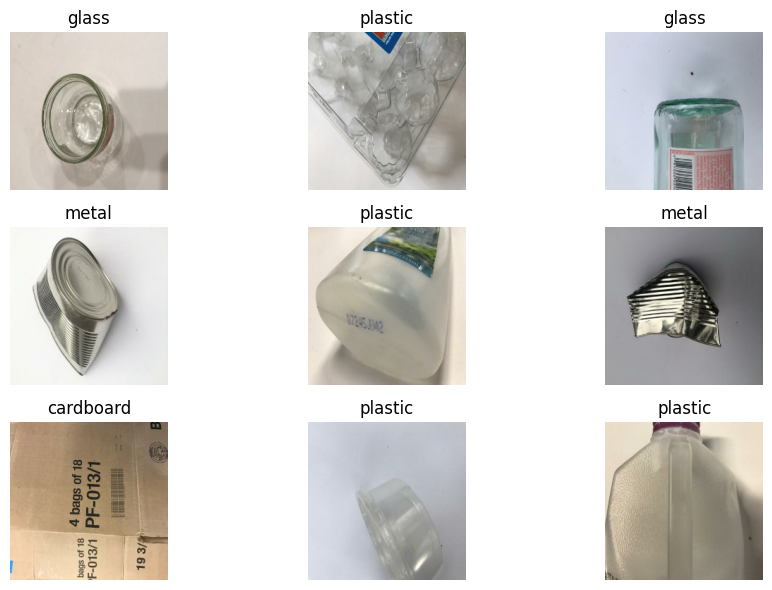

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pathlib

IMG_SIZE = 224
BATCH_SIZE = 32
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Locate the actual class-folder directory (Kaggle zip nests it two levels deep)
DATA_DIR = None
for root, dirs, filesx in os.walk("/content/garbage_data"):
    if len(dirs) == 6:  # the folder that directly contains the 6 class subfolders
        DATA_DIR = root
        break
DATA_DIR = pathlib.Path(DATA_DIR)
print("Using data directory:", DATA_DIR)
print("Classes found:", sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()]))

# Train / validation split from image_dataset_from_directory, then carve out a test split from validation
raw_train = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="training", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
)
raw_val_full = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="validation", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
)

class_names = raw_train.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

# Split the 30% "validation" portion in half -> 15% val, 15% test
val_batches = tf.data.experimental.cardinality(raw_val_full)
raw_test = raw_val_full.take(val_batches // 2)
raw_val = raw_val_full.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(raw_train).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(raw_val).numpy())
print("Test batches: ", tf.data.experimental.cardinality(raw_test).numpy())

# Performance: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train.prefetch(AUTOTUNE)
val_ds = raw_val.prefetch(AUTOTUNE)
test_ds = raw_test.prefetch(AUTOTUNE)

# Data augmentation layer (applied only during training, inside the model)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

# Visualize a few samples
plt.figure(figsize=(10, 6))
for images, labels in raw_train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


**Task 2A: CNN Built From Scratch (Baseline Model)**

Before implementing any pre-trained backbone, we first train a standard convolutional neural network **from scratch** (random initialization, no ImageNet weights) on the same preprocessed 6-class garbage data. This is the fair baseline against which all four transfer-learning models are compared.

**Architecture:** 4 convolutional blocks (Conv2D + MaxPooling, filters 32 → 64 → 128 → 128) → Global Average Pooling → Dense(128, ReLU) → Dropout(0.3) → Dense(6, softmax).

In [12]:
import time

def build_cnn_scratch(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="cnn_from_scratch")

CNN_EPOCHS = 15

cnn_model = build_cnn_scratch(IMG_SHAPE, num_classes)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()

start = time.time()
history_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS)
cnn_training_time = time.time() - start
print(f"CNN-from-scratch training time: {cnn_training_time:.1f}s")


Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,118 (1008.27 KB)

 Trainable params: 258,118 (1008.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.2516 - loss: 1.7094 - val_accuracy: 0.3610 - val_loss: 1.5710
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3493 - loss: 1.5505 - val_accuracy: 0.3102 - val_loss: 1.5573
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.3550 - loss: 1.5354 - val_accuracy: 0.3422 - val_loss: 1.5260
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.3861 - loss: 1.4970 - val_accuracy: 0.3824 - val_loss: 1.4720
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.4019 - loss: 1.4659 - val_accuracy: 0.4599 - val_loss: 1.4265
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4454 - loss: 1.3766 - val_accuracy: 0.4652 - val_loss: 1.3356
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.4822 - loss: 1.2944 - val_accuracy: 0.5401 - val_loss: 1.1625
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5161 - loss: 1.2147 - val_accuracy: 0.5481 - v

**Task 2B: Transfer Learning — Implementing Four Pre-trained Backbones**

**Instructions:**

1. Implement four pre-trained backbones as described in the referenced architecture papers: **MobileNetV2, ResNet50, VGG16, EfficientNetB0**.
2. Visualize feature maps of a few layers from one of the backbones.
3. Freeze the pre-trained convolutional base initially, train a new classification head, then unfreeze the top layers of the base and fine-tune at a low learning rate.
4. Use the same optimizer, batch size, and epoch budget across all four backbones for a fair comparison.
5. Store each trained model's history and metrics for the final comparison table.


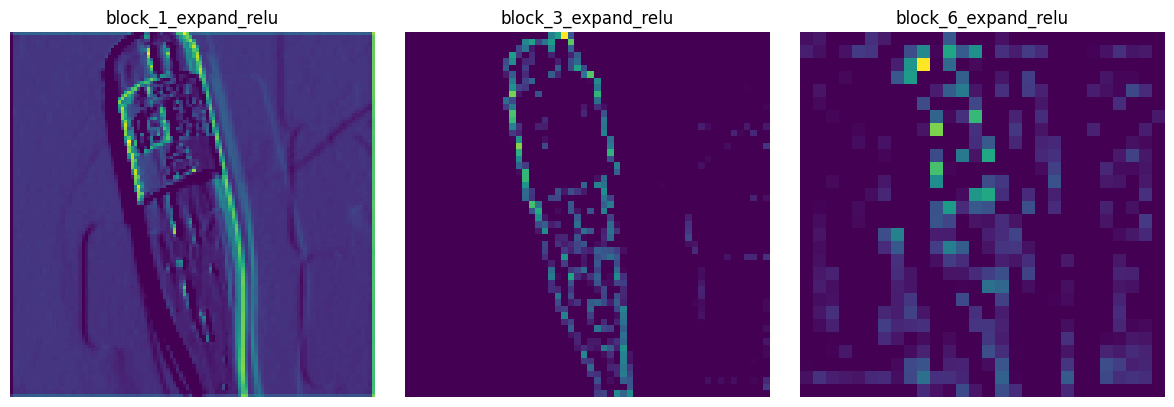

In [13]:
# ---- Visualize feature maps from a pre-trained backbone (MobileNetV2, as an example) ----
viz_base = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")

layer_names = ["block_1_expand_relu", "block_3_expand_relu", "block_6_expand_relu"]
feature_map_model = tf.keras.Model(
    inputs=viz_base.input,
    outputs=[viz_base.get_layer(name).output for name in layer_names],
)

sample_image, _ = next(iter(train_ds.unbatch().take(1)))
sample_batch = tf.expand_dims(sample_image, 0)
preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(sample_batch)
feature_maps = feature_map_model(preprocessed)

plt.figure(figsize=(12, 4))
for i, (name, fmap) in enumerate(zip(layer_names, feature_maps)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(fmap[0, :, :, 0], cmap="viridis")
    plt.title(name)
    plt.axis("off")
plt.tight_layout()
plt.show()

del viz_base, feature_map_model


In [14]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.applications import mobilenet_v2, resnet50, vgg16, efficientnet

# Each entry: (display name, model class, preprocess_input function)
BACKBONES = {
    "MobileNetV2":    (MobileNetV2,    mobilenet_v2.preprocess_input),
    "ResNet50":       (ResNet50,       resnet50.preprocess_input),
    "VGG16":          (VGG16,          vgg16.preprocess_input),
    "EfficientNetB0": (EfficientNetB0, efficientnet.preprocess_input),
}

HEAD_EPOCHS = 6
FINE_TUNE_EPOCHS = 6
FINE_TUNE_AT_FRACTION = 0.7  # unfreeze the top 30% of base-model layers during fine-tuning

def build_transfer_model(base_class, preprocess_fn, input_shape, num_classes):
    base_model = base_class(input_shape=input_shape, include_top=False, weights="imagenet")
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base_model

transfer_results = {}  # name -> dict with model, histories, timing, params

for name, (base_class, preprocess_fn) in BACKBONES.items():
    print(f"\n=== Training {name} ===")
    model, base_model = build_transfer_model(base_class, preprocess_fn, IMG_SHAPE, num_classes)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    start = time.time()
    history_head = model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS)

    # Fine-tune: unfreeze top layers of the base model
    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * FINE_TUNE_AT_FRACTION)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_fine = model.fit(train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS)
    training_time = time.time() - start

    total_params = model.count_params()
    trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)

    transfer_results[name] = {
        "model": model,
        "history_head": history_head,
        "history_fine": history_fine,
        "training_time": training_time,
        "total_params": total_params,
        "trainable_params": trainable_params,
    }
    print(f"{name} training time: {training_time:.1f}s | total params: {total_params:,} | trainable: {trainable_params:,}")



=== Training MobileNetV2 ===
Epoch 1/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.5155 - loss: 1.3225 - val_accuracy: 0.7032 - val_loss: 0.8010
Epoch 2/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.7066 - loss: 0.7889 - val_accuracy: 0.7781 - val_loss: 0.5919
Epoch 3/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7524 - loss: 0.6569 - val_accuracy: 0.8102 - val_loss: 0.5586
Epoch 4/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7648 - loss: 0.6226 - val_accuracy: 0.8075 - val_loss: 0.5562
Epoch 5/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.7971 - loss: 0.5550 - val_accuracy: 0.8209 - val_loss: 0.4938
Epoch 6/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8157 - loss: 0.5006 - val_accuracy: 0.8529 - val_loss: 0.4779
Epoch 1/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.7394 - loss: 0.7613 - val_accuracy: 0.8155 - val_loss: 0.5078
Epoch 2/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.7790 - loss: 0.6386 -

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate every trained model (CNN-from-scratch + 4 transfer-learning backbones) using: Accuracy, Precision, Recall, F1-score, Confusion Matrix.
2. Compare all five models on: Accuracy, Precision, Recall, F1-score, Training time, Number of parameters, and Loss/Accuracy curves.
3. Compare the best-performing transfer-learning model with the accuracy range reported in the reference paper(s).
4. Identify weaknesses per model and suggest improvements.

**Deliverables:** performance metrics summary table, accuracy/loss curves for every model, confusion matrices, comparison with the research paper, and a discussion.

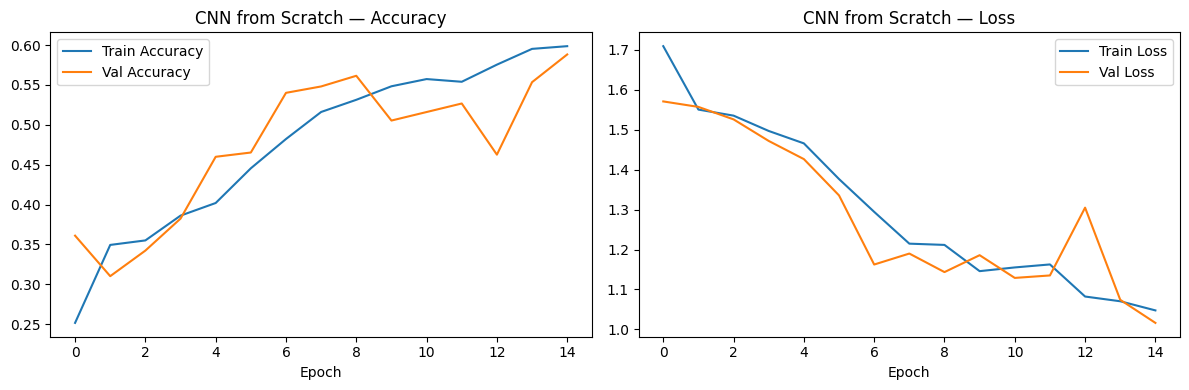

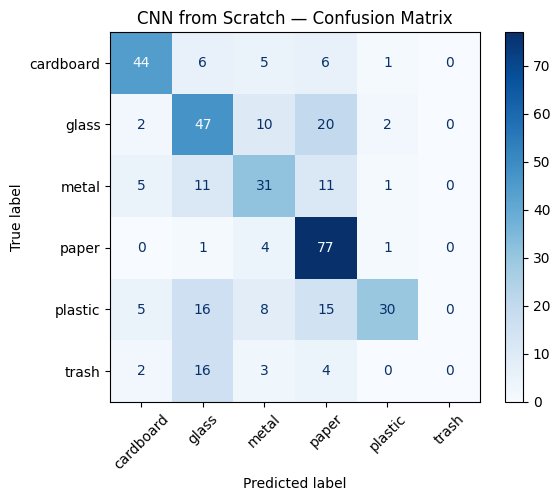

CNN Test Accuracy: 0.5964 | Precision: 0.5312 | Recall: 0.5247 | F1: 0.5069


In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

def evaluate_model(model, dataset, class_names):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, prec, rec, f1, cm

# ---- CNN-from-scratch: accuracy/loss curves ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history["accuracy"], label="Train Accuracy")
axes[0].plot(history_cnn.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("CNN from Scratch — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_cnn.history["loss"], label="Train Loss")
axes[1].plot(history_cnn.history["val_loss"], label="Val Loss")
axes[1].set_title("CNN from Scratch — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

cnn_accuracy, cnn_precision, cnn_recall, cnn_f1, cnn_cm = evaluate_model(cnn_model, test_ds, class_names)
cnn_total_params = cnn_model.count_params()
cnn_trainable_params = sum(tf.keras.backend.count_params(w) for w in cnn_model.trainable_weights)

ConfusionMatrixDisplay(cnn_cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN from Scratch — Confusion Matrix")
plt.show()

print(f"CNN Test Accuracy: {cnn_accuracy:.4f} | Precision: {cnn_precision:.4f} | Recall: {cnn_recall:.4f} | F1: {cnn_f1:.4f}")


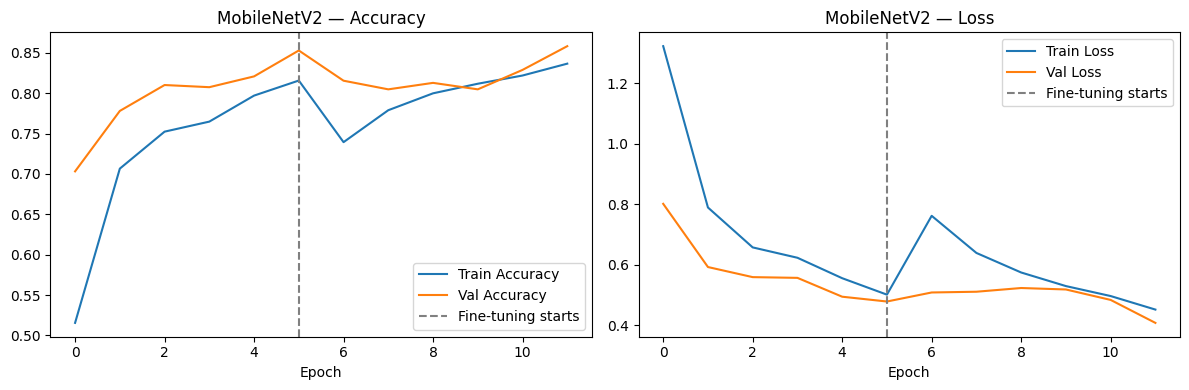

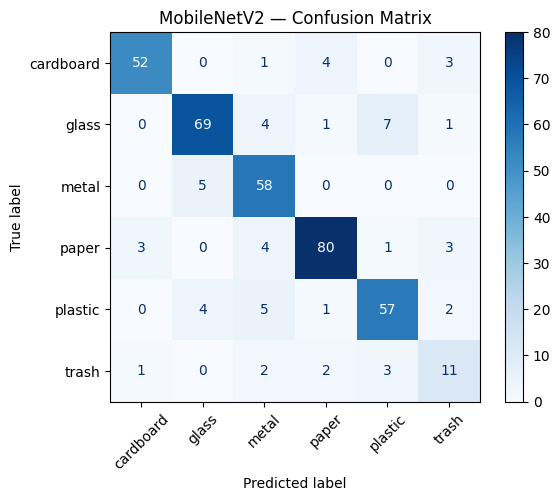

MobileNetV2: Accuracy=0.8516 Precision=0.8157 Recall=0.8188 F1=0.8160


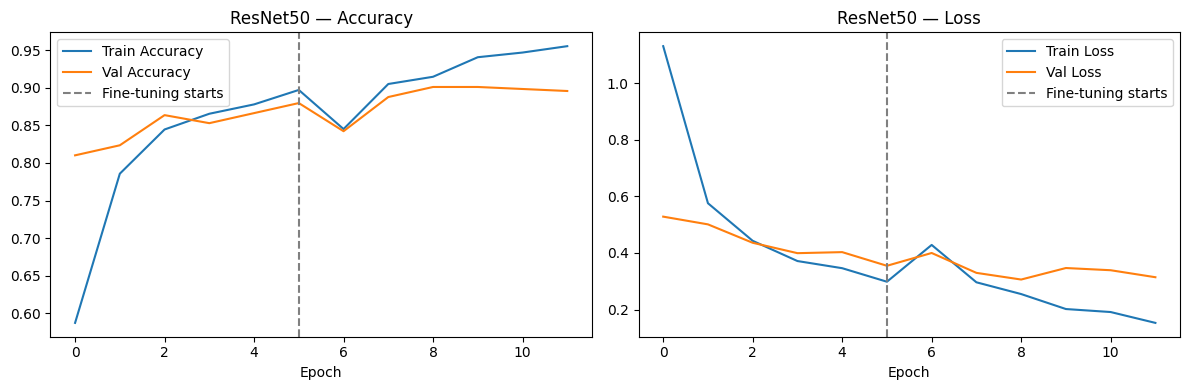

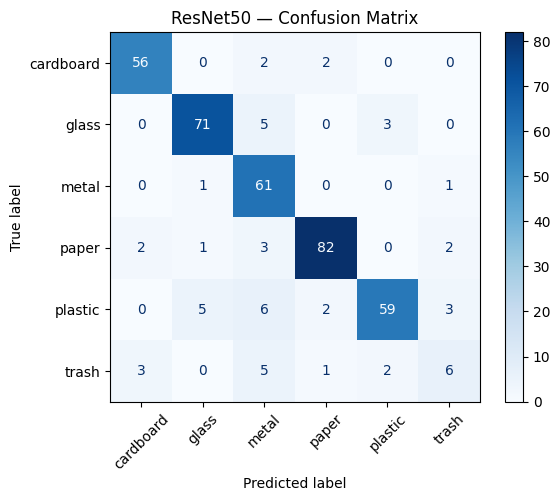

ResNet50: Accuracy=0.8724 Precision=0.8228 Recall=0.8085 F1=0.8101


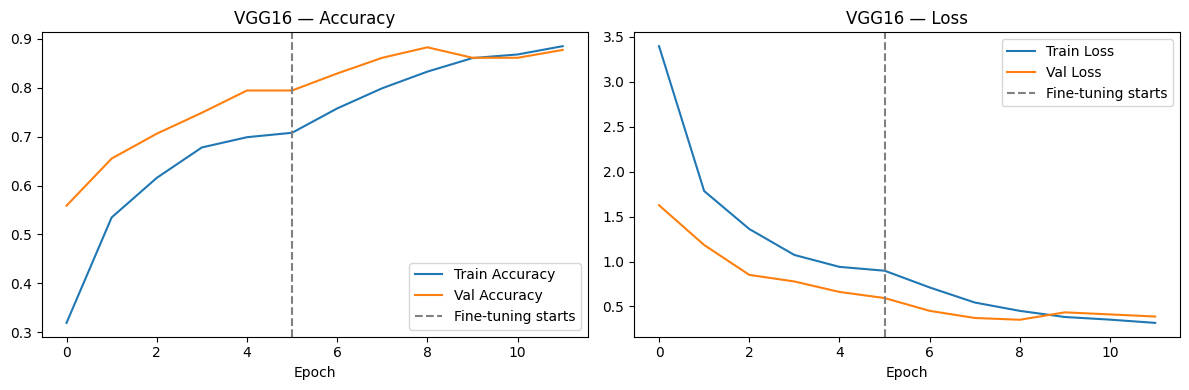

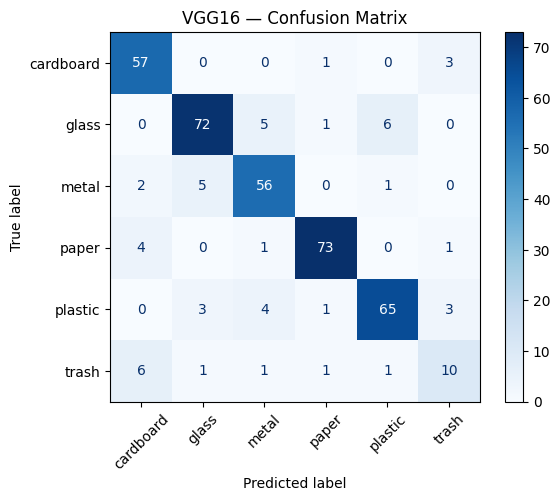

VGG16: Accuracy=0.8672 Precision=0.8296 Recall=0.8243 F1=0.8256


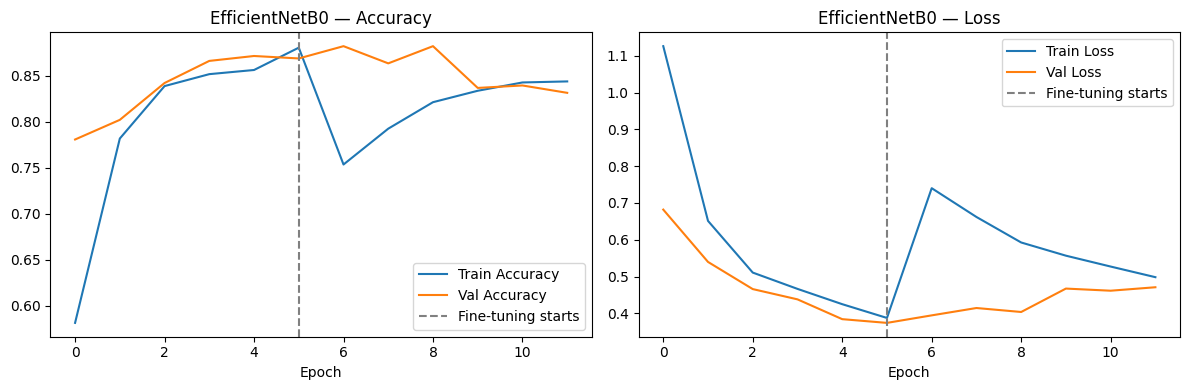

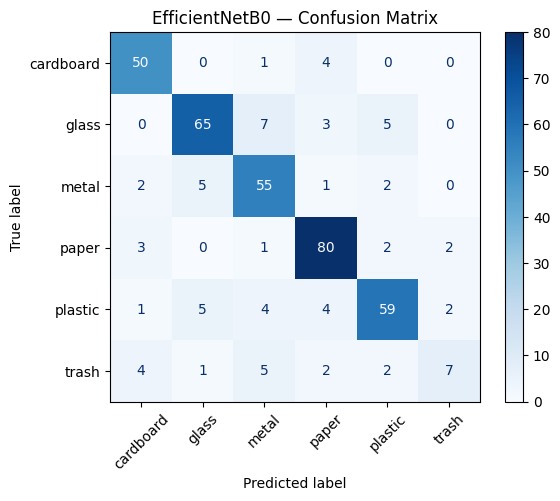

EfficientNetB0: Accuracy=0.8229 Precision=0.7954 Recall=0.7661 F1=0.7717


In [16]:
# ---- Transfer-learning models: combined accuracy/loss curves + evaluation ----
for name, res in transfer_results.items():
    acc = res["history_head"].history["accuracy"] + res["history_fine"].history["accuracy"]
    val_acc = res["history_head"].history["val_accuracy"] + res["history_fine"].history["val_accuracy"]
    loss = res["history_head"].history["loss"] + res["history_fine"].history["loss"]
    val_loss = res["history_head"].history["val_loss"] + res["history_fine"].history["val_loss"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc, label="Train Accuracy")
    axes[0].plot(val_acc, label="Val Accuracy")
    axes[0].axvline(HEAD_EPOCHS - 1, color="gray", linestyle="--", label="Fine-tuning starts")
    axes[0].set_title(f"{name} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(loss, label="Train Loss")
    axes[1].plot(val_loss, label="Val Loss")
    axes[1].axvline(HEAD_EPOCHS - 1, color="gray", linestyle="--", label="Fine-tuning starts")
    axes[1].set_title(f"{name} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    acc_score, prec, rec, f1, cm = evaluate_model(res["model"], test_ds, class_names)
    res["accuracy"], res["precision"], res["recall"], res["f1"] = acc_score, prec, rec, f1
    res["confusion_matrix"] = cm

    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    print(f"{name}: Accuracy={acc_score:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f}")


**Comparative Study — CNN (from scratch) vs. Four Transfer-Learning Backbones**

All five models are compared side-by-side on: Accuracy, Precision, Recall, F1-score, Training time, and Number of parameters/model complexity.

In [17]:
# ---- Side-by-side comparison table across all 5 models ----
rows = []
rows.append({
    "Model": "CNN from Scratch",
    "Test Accuracy": cnn_accuracy, "Test Precision": cnn_precision,
    "Test Recall": cnn_recall, "Test F1-score": cnn_f1,
    "Training Time (min)": cnn_training_time / 60,
    "Total Parameters": cnn_total_params, "Trainable Parameters": cnn_trainable_params,
})
for name, res in transfer_results.items():
    rows.append({
        "Model": name,
        "Test Accuracy": res["accuracy"], "Test Precision": res["precision"],
        "Test Recall": res["recall"], "Test F1-score": res["f1"],
        "Training Time (min)": res["training_time"] / 60,
        "Total Parameters": res["total_params"], "Trainable Parameters": res["trainable_params"],
    })

comparison_summary = pd.DataFrame(rows)
comparison_summary_display = comparison_summary.copy()
for col in ["Test Accuracy", "Test Precision", "Test Recall", "Test F1-score", "Training Time (min)"]:
    comparison_summary_display[col] = comparison_summary_display[col].map(lambda v: f"{v:.4f}")
for col in ["Total Parameters", "Trainable Parameters"]:
    comparison_summary_display[col] = comparison_summary_display[col].map(lambda v: f"{v:,}")

comparison_summary_display


,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Training Time (min),Total Parameters,Trainable Parameters
0,CNN from Scratch,0.5964,0.5312,0.5247,0.5069,1.1571,"258,118","258,118"
1,MobileNetV2,0.8516,0.8157,0.8188,0.8160,1.5189,"2,265,670","1,807,302"
2,ResNet50,0.8724,0.8228,0.8085,0.8101,2.9347,"23,600,006","17,225,734"
3,VGG16,0.8672,0.8296,0.8243,0.8256,2.4869,"14,717,766","9,442,310"
4,EfficientNetB0,0.8229,0.7954,0.7661,0.7717,1.9755,"4,057,257","3,086,818"


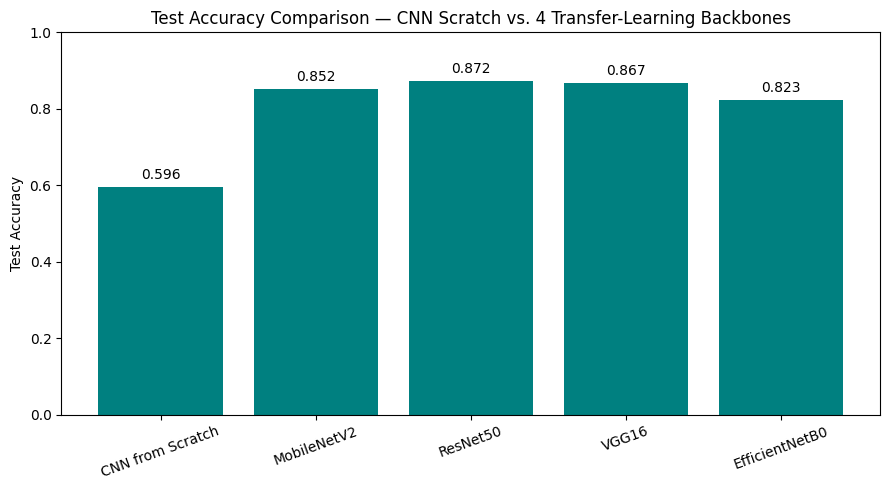

In [18]:
# ---- Bar chart: accuracy comparison across all 5 models ----
plt.figure(figsize=(9, 5))
plt.bar(comparison_summary["Model"], comparison_summary["Test Accuracy"], color="teal")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison — CNN Scratch vs. 4 Transfer-Learning Backbones")
plt.xticks(rotation=20)
plt.ylim(0, 1)
for i, v in enumerate(comparison_summary["Test Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


**Advantages and Limitations**

**CNN built from scratch**
- Advantages: full control over architecture; no dependency on external pretrained weights; far fewer parameters, simpler to reason about and deploy on constrained hardware.
- Limitations: needs more data/epochs to learn good low-level filters from random initialization; more prone to overfitting on a small (~2,500-image) dataset; usually converges to lower accuracy than any fine-tuned pretrained backbone within the same training budget.

**Transfer Learning (MobileNetV2 / ResNet50 / VGG16 / EfficientNetB0, all pretrained on ImageNet)**
- Advantages: each backbone reuses rich, general-purpose visual features already learned from 1.4M+ ImageNet images, so they converge faster and typically reach higher accuracy with fewer epochs on a small dataset like this one.
- Limitations: much larger models (VGG16 in particular) are slower to fine-tune and heavier to deploy; ResNet50/EfficientNetB0 need careful learning-rate tuning during fine-tuning to avoid catastrophic forgetting of the pretrained features; all four depend on ImageNet-domain features transferring reasonably well to garbage/waste imagery, which is not guaranteed for every material type (e.g., `trash` is the smallest, most visually diverse class here).

**Fill in after running:** note which backbone won on accuracy vs. which was fastest/lightest, and whether that tradeoff matches what you'd expect from each paper's stated design goals (e.g., MobileNetV2/EfficientNetB0 optimize for efficiency, VGG16/ResNet50 optimize for raw accuracy at higher parameter cost).

**Conclusion and Result Visualization**

The reference paper's accuracy figures are **not directly comparable on a 1:1 basis** — the original TrashNet SVM baseline (~63%) and later CNN-based follow-up work (~87-92%) were measured on slightly different splits/preprocessing of the same underlying trash-image data — but the comparison is included because it reflects the core transfer-learning claim being tested: ImageNet-pretrained backbones fine-tuned on a small, domain-specific dataset should outperform both a classical baseline and a from-scratch CNN trained on the same limited data.

**Discussion — fill in after running:**
- Report the final test accuracy/precision/recall/F1 for **all five** models from the comparison table above.
- State which transfer-learning backbone performed best, and whether it beat the from-scratch CNN and how it compares to the ~87-92% CNN-based figures reported for this dataset in later work.
- Note which classes were most often confused (see confusion matrices) and suggest one concrete improvement (e.g., more `trash`-class images, stronger augmentation, or a longer fine-tuning schedule).

**Declaration**

I, `Sanskar Ramesh Meharkar`, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: `Sanskar Ramesh meharkar`